# **Project 2 | Content-Based and Collaborative Filtering**

# by Sandra Dela Cruz

In [321]:
# import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from difflib import get_close_matches
from scipy.sparse import csr_matrix

In [322]:
# import dataset from GitHub
# original data source: https://grouplens.org/datasets/movielens/
!git clone https://github.com/lalaexplore/DATA-612.git

links = pd.read_csv('DATA-612/project 2/links.csv')
movies = pd.read_csv('DATA-612/project 2/movies.csv')
ratings = pd.read_csv('DATA-612/project 2/ratings.csv')
tags = pd.read_csv('DATA-612/project 2/tags.csv')

full_df = pd.merge(movies, ratings, on='movieId', how='left')

full_df.info()
full_df.head()

fatal: destination path 'DATA-612' already exists and is not an empty directory.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100854 entries, 0 to 100853
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    100854 non-null  int64  
 1   title      100854 non-null  object 
 2   genres     100854 non-null  object 
 3   userId     100836 non-null  float64
 4   rating     100836 non-null  float64
 5   timestamp  100836 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 4.6+ MB


,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09


# Data Preprocessing

In [323]:
# Let's see if we have any missing values before splitting the dataset
full_df.isnull().values.any()
full_df.isnull().sum() # shows missing values for each column
full_df.isnull().sum().sum() # we have at least 54 missing values for userId, rating and timestamp
full_df[full_df.isnull().any(axis=1)].head()
# We have 54 missing values for userId, rating and timestamp. We will drop these rows for now since they are not useful for this analysis.

full_df.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09


In [324]:
# Drop missing values for our analysis
full_df = full_df.dropna(subset=['userId'])

full_df.isnull().sum() # we have no more missing values for userId, rating and timestamp

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [325]:
# Let's clean our dataset first
full_df['userId'] = full_df['userId'].astype(int)
full_df['movieId'] = full_df['movieId'].astype(int)
full_df['rating'] = full_df['rating'].astype(float)


# Transform timestamp (just in case)
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], unit='s')
full_df['year'] = full_df['timestamp'].dt.year
full_df['month'] = full_df['timestamp'].dt.month
full_df['day'] = full_df['timestamp'].dt.day
full_df['hour'] = full_df['timestamp'].dt.hour
full_df['minute'] = full_df['timestamp'].dt.minute
full_df['second'] = full_df['timestamp'].dt.second

full_df.head()

,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03,2000,7,30,18,45,3
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02,1996,11,8,6,36,2
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26,2005,1,25,6,52,26
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30,2017,11,13,12,59,30
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03,2011,5,18,5,28,3


In [326]:
# Final check before we proceed
full_df.info()
full_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 100836 entries, 0 to 100853
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   movieId    100836 non-null  int64         
 1   title      100836 non-null  object        
 2   genres     100836 non-null  object        
 3   userId     100836 non-null  int64         
 4   rating     100836 non-null  float64       
 5   timestamp  100836 non-null  datetime64[ns]
 6   year       100836 non-null  int32         
 7   month      100836 non-null  int32         
 8   day        100836 non-null  int32         
 9   hour       100836 non-null  int32         
 10  minute     100836 non-null  int32         
 11  second     100836 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(6), int64(2), object(2)
memory usage: 7.7+ MB


,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03,2000,7,30,18,45,3
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02,1996,11,8,6,36,2
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26,2005,1,25,6,52,26
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30,2017,11,13,12,59,30
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03,2011,5,18,5,28,3


# Data Split

In [327]:
# Let's split the dataset into training and testing sets
# Let's guarantee that the userId and movieId are consistent across both sets

train = []
test = []

for uid, group in full_df.groupby('userId'):
    group = group.sample(frac=1, random_state=52) # shuffle the group

    if len(group) < 2:
        train.append(group) # if the user has only 1 rating, put it in the training set
        continue

    split = int(len(group) * 0.8) # 80% for training, 20% for testing

    train.append(group.iloc[:split]) # use iloc for positional indexing (split by row)
    test.append(group.iloc[split:])

train = pd.concat(train, ignore_index=True)
test = pd.concat(test, ignore_index=True)

# Let's see if splitting worked
print("Train size:", len(train))
print("Test size:", len(test))

print("Total:", len(train) + len(test))
print("Original:", len(full_df))

Train size: 80419
Test size: 20417
Total: 100836
Original: 100836


In [328]:
# See if there are users in the test set that are not in the training set
train_users = set(train['userId']) 
test_users = set(test['userId'])

print ("Users only in test:",
       len(test_users - train_users))


Users only in test: 0


In [329]:
# See if there are movies in test set that are not in the training set
train_movies = set(train['movieId'])
test_movies = set(test['movieId'])

print ("Movies only in test:",
       len(test_movies - train_movies))

Movies only in test: 761


In [330]:
# Since there are movies only seen in test set, let's remove them
# Keep only test ratings for movies seen in training
test = test[
    test['userId'].isin(train_users) & # Just to make sure for user-user CF
    test['movieId'].isin(train_movies)]


# Verify rows removed
print("Train size:", len(train))
print("Test size after filtering:", len(test))

Train size: 80419
Test size after filtering: 19585


In [331]:
# Check again for our dataset
print(
    "Unseen users:",
    len(set(test['userId']) - set(train['userId']))
)

print(
    "Unseen movies:",
    len(set(test['movieId']) - set(train['movieId']))
)

# Finally, there are no userId and movieId that are not seen on our training data

Unseen users: 0
Unseen movies: 0


# Part 1: User-user Collaborative Filtering

In [332]:
# Build user-item matrix
user_item_matrix = train.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,190219,191005,193565,193567,193571,193573,193579,193581,193583,193585
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Centered Cosine Similarity a.k.a. Pearson Correlation

In [333]:
# Compute user-user Pearson similarity matrix
# No manual centering needed for preprocessing
user_similarity_pearson = user_item_matrix.T.corr(method='pearson')

user_similarity_pearson.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,NaN,0.129969,0.061020,0.866025,-0.538952,-0.168345,0.593080,0.918559,NaN,...,1.889822e-01,0.481589,-0.031204,-8.485281e-01,-0.334431,0.028805,0.072604,0.278198,1.000000,-0.250788
2,NaN,1.0,NaN,NaN,NaN,NaN,-0.991241,NaN,NaN,NaN,...,-7.319251e-01,NaN,-1.000000,NaN,NaN,0.755929,NaN,-0.080064,NaN,0.621177
3,0.129969,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.944911
4,0.061020,NaN,NaN,1.000000,-0.327327,-0.070328,0.313392,-0.060193,NaN,0.792406,...,5.925932e-18,0.593474,0.140491,0.000000e+00,0.332363,0.348387,0.354809,-0.214214,1.000000,-0.076826
5,0.866025,NaN,NaN,-0.327327,1.000000,0.137959,0.117202,0.138409,NaN,-1.000000,...,-1.000000e+00,0.082011,0.409673,9.559344e-18,-0.728219,0.197949,-0.040893,-0.159126,-0.408248,0.594089


In [334]:
# Let's predict the ratings for the movies that the user haven't seen yet according to its nearest 10 neighbours using Pearson correlation and mean centering
def predict_rating_pearson(
        user_id,
        movie_id,
        user_item_matrix,
        user_similarity,
        k=10
):
    """
    Predict a user's rating for a movie using
    user-based collaborative filtering with
    Pearson correlation and mean-centering.
    """

    # Check if user exists in similarity matrix
    if user_id not in user_similarity.index:
        return np.nan
    
    # Check if movie exists in similarity matrix
    if movie_id not in user_item_matrix.columns:
        return np.nan
    
    # Get similarities for the target user
    sim_scores = user_similarity.loc[user_id].drop(user_id)

    # Optiional: keep only positively correlated neighbors
    sim_scores = sim_scores[sim_scores>0]

    # Select top-k most similar users
    top_k_users = sim_scores.sort_values(ascending=False).head(k)

    if len(top_k_users) == 0:
        return user_item_matrix.loc[user_id].mean()
    
    # Ratings given to the target movie by neighbors
    neighbor_ratings = user_item_matrix.loc[
        top_k_users.index,
        movie_id
    ]

    # Keep only neighbors who rated the movie
    valid_mask = neighbor_ratings.notna()

    if valid_mask.sum() == 0:
        # Fallback: user's average rating
        return user_item_matrix.loc[user_id].mean()
    
    ratings = neighbor_ratings[valid_mask]
    similarities = top_k_users.loc[ratings.index]

    # Mean rating of each neighbor
    neighbor_means = user_item_matrix.loc[
        ratings.index
    ].mean(axis=1)

    # Mean rating of target user
    user_mean = user_item_matrix.loc[user_id].mean()

    # Mean-centered collaborative filtering prediction. We need this beacuse we are predicting
    numerator = np.dot(
        similarities,
        ratings - neighbor_means
    )

    denominator = np.sum(np.abs(similarities))

    if denominator == 0:
        return user_mean

    prediction = user_mean + (numerator / denominator)

    return prediction



## Sample Use: Predict User Unrated Movies Using Pearson Correlation

In [335]:
# Get unrated movies for a particular user
target_user = 189

unrated_movies = user_item_matrix.loc[target_user][
    user_item_matrix.loc[target_user].isna()
].index

In [336]:
def recommend_movies(
    user_id,
    user_item_matrix,
    user_similarity,
    k=10,
    n_recommendations=10
):
    
    unrated_movies = user_item_matrix.loc[user_id][
        user_item_matrix.loc[user_id].isna()
    ].index

    predictions = {}

    for movie_id in unrated_movies:
        pred = predict_rating_pearson(
            user_id=user_id,
            movie_id=movie_id,
            user_item_matrix=user_item_matrix,
            user_similarity=user_similarity,
            k=k
        )

        predictions[movie_id] = pred

    recommendations_pc = (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

    return recommendations_pc

In [337]:
# Sort recommendations
recommendations_pc = recommend_movies(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_pearson,
    k=10,
    n_recommendations=10
)

print(recommendations_pc)

307      5.816817
4144     5.816817
306      5.816817
6669     5.816817
48385    5.509979
2762     5.509979
1411     5.509979
1027     5.509979
1202     5.442214
1225     5.442214
dtype: float64


In [338]:
# Convert IDs to titles
top_movie_ids_pc = recommendations_pc.index

movies[
    movies["movieId"].isin(top_movie_ids_pc)
][["movieId", "title"]]

,movieId,title
266,306,Three Colors: Red (Trois couleurs: Rouge) (1994)
267,307,Three Colors: Blue (Trois couleurs: Bleu) (1993)
784,1027,Robin Hood: Prince of Thieves (1991)
904,1202,Withnail & I (1987)
926,1225,Amadeus (1984)
1086,1411,Hamlet (1996)
2078,2762,"Sixth Sense, The (1999)"
3087,4144,In the Mood For Love (Fa yeung nin wa) (2000)
4507,6669,Ikiru (1952)
6310,48385,Borat: Cultural Learnings of America for Make ...


## Cosine Similarity

In [339]:
# Center the user-item matrix before cosine similarity
user_mean = user_item_matrix.mean(axis=1)

centered_matrix = user_item_matrix.sub(user_mean, axis=0)

centered_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,190219,191005,193565,193567,193571,193573,193579,193581,193583,193585
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.394595,NaN,-0.394595,NaN,NaN,-0.394595,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.371429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [340]:
# Sparse matrix for user-item interactions
sparse_matrix = csr_matrix(centered_matrix.fillna(0).values) # 0 here has no meaning or value for sparse matrix

# User-user similarity cosine
user_similarity_cosine = cosine_similarity(sparse_matrix)

# DataFrame for user-user similarity
user_similarity_cosine = pd.DataFrame(
    user_similarity_cosine,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_cosine.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.002384,0.006643,0.015333,0.036294,-0.053628,0.002205,0.056559,0.023657,-0.024129,...,0.027510,0.023444,-0.006145,-0.010779,-0.044566,0.003339,0.020288,0.068886,0.026386,0.001060
2,-0.002384,1.000000,0.000000,-0.017657,0.039214,-0.040331,-0.006047,-0.099392,0.000000,-0.031250,...,-0.067492,-0.054143,-0.002596,0.000000,0.000000,0.007394,-0.038240,-0.020732,-0.120054,0.020010
3,0.006643,0.000000,1.000000,-0.013767,0.000000,0.006681,0.000000,-0.043020,0.000000,0.000000,...,-0.022374,-0.017094,0.002989,0.000000,0.000000,-0.010291,0.009684,0.001871,0.000000,0.018680
4,0.015333,-0.017657,-0.013767,1.000000,0.007549,-0.006074,0.021375,-0.000524,-0.006765,0.019573,...,-0.006060,0.047614,0.031393,0.000015,0.034864,0.045689,0.023473,-0.038158,0.025739,-0.006407
5,0.036294,0.039214,0.000000,0.007549,1.000000,0.036874,0.002357,0.015687,0.000000,-0.040620,...,-0.021404,-0.027097,0.030101,0.002455,-0.050646,0.011584,-0.009528,-0.019929,-0.054926,0.015802


In [341]:
def predict_rating_cosine( 
        user_id, 
        movie_id, 
        user_item_matrix, 
        user_similarity, 
        k=10 
        ): 
        """ 
        Predict a user's rating for a movie using user-based collaborative filtering with Cosine similarity. 
        """ 
        
        if user_id not in user_similarity.index: 
            return np.nan 
        if movie_id not in user_item_matrix.columns:
            return np.nan
        
        sim_scores = user_similarity.loc[user_id].drop(user_id) 
        
        top_k_users = sim_scores.sort_values(ascending=False).head(k) 
        
        neighbor_ratings = user_item_matrix.loc[
             top_k_users.index, 
             movie_id 
             ] 
        
        valid = neighbor_ratings.notna() 
        
        if valid.sum() == 0: return user_item_matrix.loc[user_id].mean() 
        
        ratings = neighbor_ratings[valid] 
        sims = top_k_users.loc[ratings.index] 
        
        numerator = np.dot(ratings, sims) 
        denominator = np.sum(np.abs(sims)) 
        
        if denominator == 0:
            return user_item_matrix.loc[user_id].mean() 
        
        return numerator / denominator

## Sample Use: Predict User Unrated Movies Using Cosine Correlation

In [342]:
def recommend_movies(
    user_id,
    user_item_matrix,
    user_similarity,
    k=10,
    n_recommendations=10
):
    
    unrated_movies = user_item_matrix.loc[user_id][
        user_item_matrix.loc[user_id].isna()
    ].index

    predictions = {}

    for movie_id in unrated_movies:
        pred = predict_rating_cosine(
            user_id=user_id,
            movie_id=movie_id,
            user_item_matrix=user_item_matrix,
            user_similarity=user_similarity,
            k=k
        )

        predictions[movie_id] = pred

    recommendations_cs = (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

    return recommendations_cs

In [343]:
# Sort recommendations
recommendations_cs = recommend_movies(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_pearson,
    k=10,
    n_recommendations=10
)

print(recommendations_cs)

1027     5.0
968      5.0
953      5.0
2313     5.0
1247     5.0
345      5.0
1202     5.0
1225     5.0
99636    5.0
2762     5.0
dtype: float64


In [344]:
# Convert IDs to titles
top_movie_ids_cs = recommendations_cs.index

movies[
    movies["movieId"].isin(top_movie_ids_cs)
][["movieId", "title"]]

,movieId,title
303,345,"Adventures of Priscilla, Queen of the Desert, ..."
733,953,It's a Wonderful Life (1946)
741,968,Night of the Living Dead (1968)
784,1027,Robin Hood: Prince of Thieves (1991)
904,1202,Withnail & I (1987)
926,1225,Amadeus (1984)
946,1247,"Graduate, The (1967)"
1721,2313,"Elephant Man, The (1980)"
2078,2762,"Sixth Sense, The (1999)"
8074,99636,English Vinglish (2012)


# Part 2: Item-item Collaborative Filtering

## Cosine Similarity

In [345]:
# Calculate cosine similarity
item_similarity = cosine_similarity(sparse_matrix.T) # we need to transpose the matrix to get item-item similarity instead of user-user similarity

item_similarity = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

item_similarity.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,190219,191005,193565,193567,193571,193573,193579,193581,193583,193585
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.064023,0.031811,-0.040703,-0.151963,0.091329,-0.050419,0.003146,-0.080319,-0.046948,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.064023,1.000000,0.059698,-0.115901,0.082419,-0.028478,-0.005254,0.051469,-0.017848,-0.138956,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.031811,0.059698,1.000000,-0.040284,0.090633,-0.006069,0.016957,-0.042166,-0.075511,-0.115218,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.040703,-0.115901,-0.040284,1.000000,0.022253,-0.018724,0.006060,0.029673,0.000000,0.129966,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.151963,0.082419,0.090633,0.022253,1.000000,-0.052541,0.112493,-0.003412,0.163362,0.028298,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [346]:
def predict_rating_item_cosine(
        user_id,
        movie_id,
        user_item_matrix,
        item_similarity,
        k=10
):
    
    """
    Item-item collaborative filtering using cosine similarity.
    Predict rating for a user-movie pair.
    """

    # Check if user and movie exist
    if user_id not in user_item_matrix.index:
        return np.nan
    
    if movie_id not in user_item_matrix.columns:
        return np.nan
    
    # Get user's ratings
    user_ratings = user_item_matrix.loc[user_id]

    # Get similarity scores for target movie
    sim_scores = item_similarity.loc[movie_id].drop(movie_id)

    # Keep only movies the user had rated
    rated_items = user_ratings[user_ratings.notna()].index

    sim_scores = sim_scores.loc[sim_scores.index.intersection(rated_items)]

    if len(sim_scores) == 0:
        return user_ratings.mean()
    
    # Select top-k similar items
    top_k_items = sim_scores.sort_values(ascending=False).head(k)

    # Corresponding user ratings
    ratings = user_ratings.loc[top_k_items.index]

    # Compute weighted sum
    numerator = np.dot(top_k_items, ratings)
    denominator = np.sum(np.abs(top_k_items))

    if denominator == 0:
        return user_ratings.mean()
    
    return numerator/denominator

# uses cosine similarity weights
# uses weighted average


## Sample Use: Predicted Movies Using Cosine Correlation

In [347]:
predictions = {}

for movie in unrated_movies:
    predictions[movie] = predict_rating_item_cosine(
        user_id=target_user,
        movie_id=movie,
        user_item_matrix=user_item_matrix,
        item_similarity=item_similarity,
        k=10
    )

In [348]:
recommendations_item_cs = (
    pd.Series(predictions)
    .sort_values(ascending=False)
)

recommendations_item_cs.head(10)

6344      5.000000
6379      5.000000
88179     5.000000
55555     5.000000
27695     5.000000
131724    5.000000
60857     5.000000
60894     5.000000
51705     4.886889
71619     4.886889
dtype: float64

In [349]:
top_movie_ids_item_cs = recommendations_item_cs.head(10).index

movies[
    movies['movieId'].isin(top_movie_ids_item_cs)
][['movieId', 'title']]

,movieId,title
4343,6344,101 Reykjavik (101 Reykjavík) (2000)
4362,6379,Wrong Turn (2003)
5677,27695,Nicotina (2003)
6437,51705,Priceless (Hors de prix) (2006)
6603,55555,"Edge of Heaven, The (Auf der anderen Seite) (2..."
6807,60857,"Tracey Fragments, The (2007)"
6809,60894,"Edge of Love, The (2008)"
7157,71619,Coco Before Chanel (Coco avant Chanel) (2009)
7648,88179,One Day (2011)
8828,131724,The Jinx: The Life and Deaths of Robert Durst ...


# Part 3: Overall RMSE and MAE Evaluation

In [350]:
# Build prediction function (this works for any prediction function)
def evaluate_rmse_mae(
        test_data,
        prediction_fuction,
        **kwargs
):
    actual = []
    predicted = []

    for row in test_data.itertuples():
        
        pred = prediction_fuction(
            user_id=row.userId,
            movie_id=row.movieId,
            **kwargs
        )

        if not np.isnan(pred):
            actual.append(row.rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    return rmse, mae

In [351]:
# Pearson User-user
pc_user_rmse, pc_user_mae = evaluate_rmse_mae(
    test,
    predict_rating_pearson,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_pearson,
    k=10
)

print(f"RMSE User-user CF Using Pearson Correlation: {pc_user_rmse:.3f}")
print(f"MAE User-user CF Using Pearson Correlation: {pc_user_mae:.3f}")

RMSE User-user CF Using Pearson Correlation: 0.986
MAE User-user CF Using Pearson Correlation: 0.764


In [352]:
# Cosine User-user
cs_user_rmse, cs_user_mae = evaluate_rmse_mae(
    test,
    predict_rating_cosine,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_cosine,
    k=10
)

print(f"RMSE User-user CF Using Cosine Similarity: {cs_user_rmse:.3f}")
print(f"MAE User-user CF Using Cosine Similarity: {cs_user_mae:.3f}")

RMSE User-user CF Using Cosine Similarity: 1.012
MAE User-user CF Using Cosine Similarity: 0.774


In [353]:
# Cosine Item-item
cs_item_rmse, cs_item_mae = evaluate_rmse_mae(
    test,
    predict_rating_item_cosine,
    user_item_matrix=user_item_matrix,
    item_similarity=item_similarity,
    k=10
)

print(f"RMSE Item-item CF Using Cosine Similarity: {cs_item_rmse:.3f}")
print(f"MAE Item-item CF Using Cosine Similarity: {cs_item_mae:.3f}")

RMSE Item-item CF Using Cosine Similarity: 0.870
MAE Item-item CF Using Cosine Similarity: 0.653


## Part 4: Overall Precision@K and Recall@K

In [364]:
def get_top_k_recommendations(
        user_id,
        prediction_function,
        user_item_matrix,
        k_recommendations=20,
        candidate_size=3000,
        **kwargs
):
     # grab the user's row once
    user_ratings = user_item_matrix.loc[user_id]

    # find unrated movies efficiently
    unrated_movies = user_ratings[user_ratings.isna()].index

    if len(unrated_movies) > candidate_size:
        unrated_movies = np.random.choice(
             unrated_movies,
            size=candidate_size,
            replace=False
        )
    
    predictions = {}

    for movie_id in unrated_movies:

        pred = prediction_function(
            user_id=user_id,
            movie_id=movie_id,
            user_item_matrix=user_item_matrix,
            **kwargs
        )

        if not np.isnan(pred):
            predictions[movie_id] = pred

    if len(predictions) == 0:
        return []
    
    return (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(k_recommendations)
        .index
        .tolist()
    )

In [365]:
def precision_recall_at_k(
    test_data,
    prediction_function,
    k=20,
    threshold=3.5,
    **kwargs
):

    precisions = []
    recalls = []

    users = test_data['userId'].unique()

    for user in users:

        if user not in kwargs["user_item_matrix"].index:
            continue

        actual_relevant = set(
            test_data[
                (test_data['userId'] == user) &
                (test_data['rating'] >= threshold)
            ]['movieId']
        )

        if len(actual_relevant) == 0:
            continue

        recommended = set(
            get_top_k_recommendations(
                user_id=user,
                prediction_function=prediction_function,
                k_recommendations=k,
                **kwargs
            )
        )

        true_positives = len(
            recommended.intersection(actual_relevant)
        )

        precisions.append(true_positives / k)

        recalls.append(
            true_positives / len(actual_relevant)
        )


    return np.mean(precisions), np.mean(recalls)

In [366]:
pc_user_precision, pc_user_recall = precision_recall_at_k(
    test,
    predict_rating_pearson,
    k=20,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_pearson,
)

print(f"Precision@10 User-user CF Using Pearson Correlation: {pc_user_precision:.3f}")
print(f"Recall@10 User-user CF Using Pearson Correlation: {pc_user_recall:.3f}")

Precision@10 User-user CF Using Pearson Correlation: 0.019
Recall@10 User-user CF Using Pearson Correlation: 0.018


In [367]:
cs_user_precision, cs_user_recall = precision_recall_at_k(
    test,
    predict_rating_cosine,
    k=20,
    user_item_matrix=user_item_matrix,
    user_similarity=user_similarity_pearson,
)

print(f"Precision@10 User-user CF Using Cosine Similarity: {cs_user_precision:.3f}")
print(f"Recall@10 User-user CF Using Cosine Similarity: {cs_user_recall:.3f}")

Precision@10 User-user CF Using Cosine Similarity: 0.019
Recall@10 User-user CF Using Cosine Similarity: 0.020


In [368]:
cs_item_precision, cs_item_recall = precision_recall_at_k(
    test,
    predict_rating_item_cosine,
    k=20,
    user_item_matrix=user_item_matrix,
    item_similarity=item_similarity,
)

print(f"Precision@10 Item-item CF Using Cosine Similarity: {cs_item_precision:.3f}")
print(f"Recall@10 Item-item CF Using Cosine Similarity: {cs_item_recall:.3f}")

Precision@10 Item-item CF Using Cosine Similarity: 0.005
Recall@10 Item-item CF Using Cosine Similarity: 0.002


## Part 5: Final Comparison Table and Graph

In [369]:
results = pd.DataFrame({
    "RMSE": [
        pc_user_rmse,
        cs_user_rmse,
        cs_item_rmse
    ],
    "MAE": [
        pc_user_mae,
        cs_user_mae,
        cs_item_mae
    ],
    "Precision@10": [
        pc_user_precision,
        cs_user_precision,
        cs_item_precision
    ],
    "Recall@10": [
        pc_user_recall,
        cs_user_recall,
        cs_item_recall
    ]
},
index=[
    "User-User Pearson",
    "User-User Cosine",
    "Item-Item Cosine"
])

results

,RMSE,MAE,Precision@10,Recall@10
User-User Pearson,0.986071,0.764373,0.018865,0.017802
User-User Cosine,1.011690,0.774263,0.018698,0.020406
Item-Item Cosine,0.870164,0.653322,0.004925,0.001913


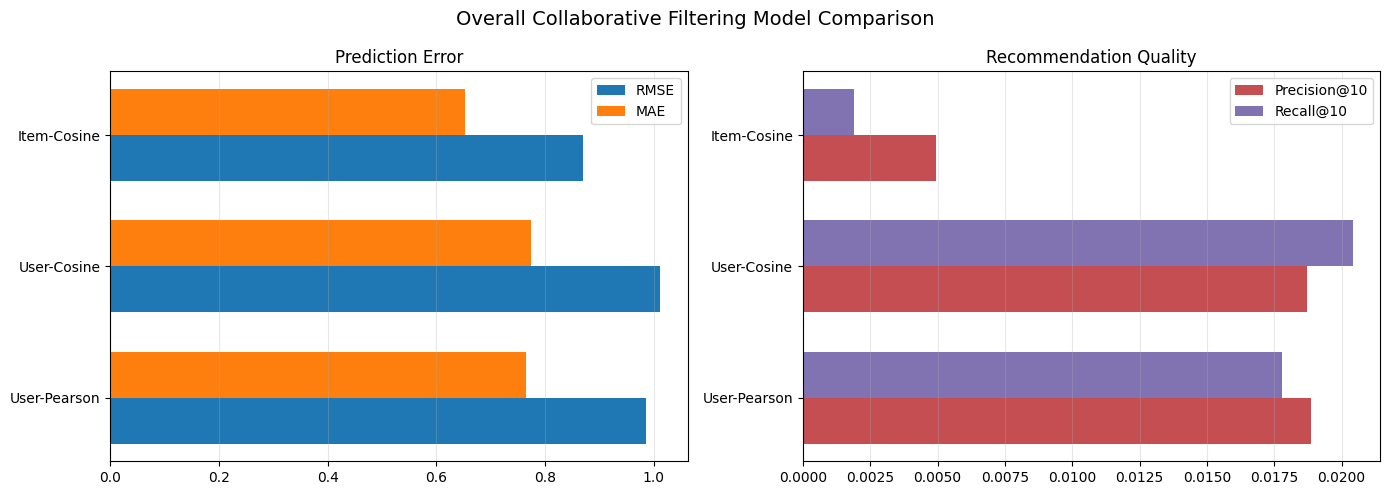

In [370]:
models = ["User-Pearson", "User-Cosine", "Item-Cosine"]

rmse_scores = [pc_user_rmse, cs_user_rmse, cs_item_rmse]
mae_scores = [pc_user_mae, cs_user_mae, cs_item_mae]

precision = [pc_user_precision, cs_user_precision, cs_item_precision]
recall = [pc_user_recall, cs_user_recall, cs_item_recall]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y = np.arange(len(models))
h = 0.35

# Left: RMSE & MAE (Error Metrics)
axes[0].barh(y - h/2, rmse_scores, h, label="RMSE")
axes[0].barh(y + h/2, mae_scores, h, label="MAE")
axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
axes[0].set_title("Prediction Error")
axes[0].grid(axis="x", alpha=0.3)
axes[0].legend()

# Right: Precision & Recall (Recommendatin Metrics)
axes[1].barh(y - h/2, precision, h, label="Precision@10", color="#C44E52")
axes[1].barh(y + h/2, recall, h, label="Recall@10", color="#8172B2")
axes[1].set_yticks(y)
axes[1].set_yticklabels(models)
axes[1].set_title("Recommendation Quality")
axes[1].grid(axis="x", alpha=0.3)
axes[1].legend()

plt.suptitle("Overall Collaborative Filtering Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# Extra: Item-item Similarity Graph Example

In [371]:
def plot_similar_movies_graph(
    movie_id,
    item_similarity,
    movie_titles,
    top_n=5
):

    # Get top similar movies (skip itself)
    top_similar = (
        item_similarity[movie_id]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    G = nx.Graph()

    # Add main movie
    G.add_node(movie_id)

    # Add similar movies
    for sim_id, score in top_similar.items():
        G.add_edge(movie_id, sim_id, weight=score)

    # Labels (movie titles)
    labels = {
        node: movie_titles.get(node, str(node))
        for node in G.nodes()
    }

    plt.figure(figsize=(12, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        labels=labels,
        node_size=2500,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        width=1
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels={k: round(v, 2) for k, v in edge_labels.items()}
    )

    plt.title("Item-Item Similarity Graph Example", fontsize=16, fontweight="bold")
    plt.show()

In [372]:
movie_titles = movies.set_index('movieId')['title'].to_dict()

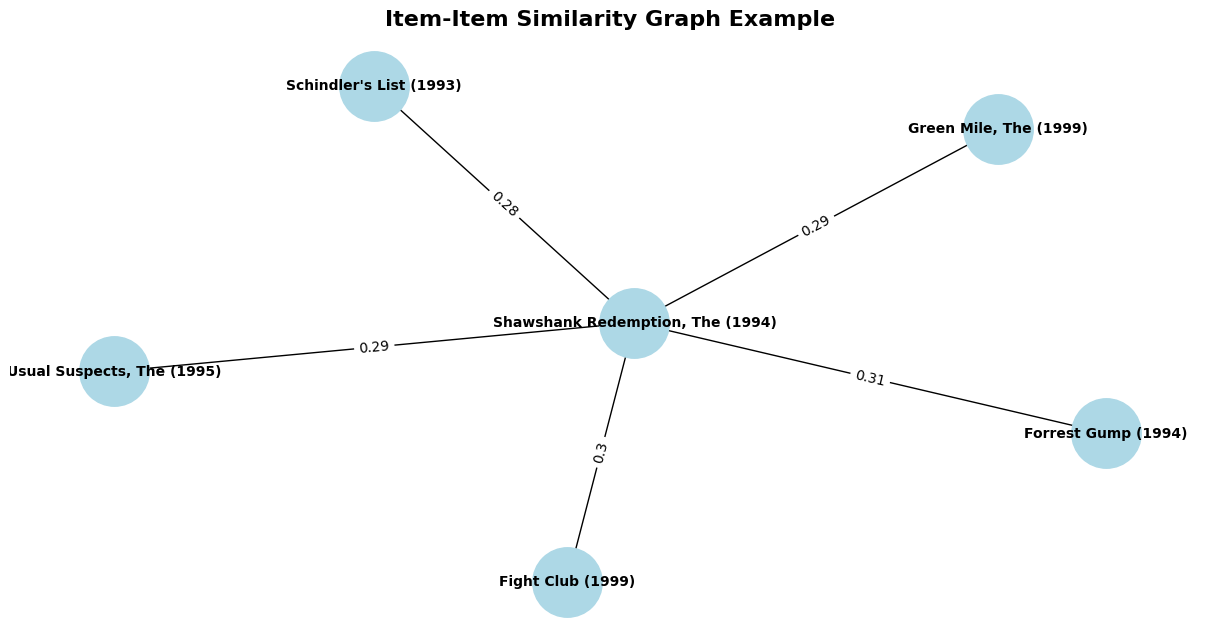

In [373]:
plot_similar_movies_graph(
    movie_id=318,
    item_similarity=item_similarity,
    movie_titles=movie_titles,
    top_n=5
)

# Summary

Three collaborative filtering approaches were evaluated: User–User Pearson Correlation, User–User Cosine Similarity, and Item–Item Cosine Similarity. Performance was assessed using RMSE and MAE to measure rating prediction accuracy, and Precision@20 and Recall@20 to evaluate recommendation quality. A candidate set size of 3,000 items was used to improve computational efficiency, and the top-20 recommendations (k = 20) were considered when computing ranking metrics.

Metrics were computed across all users in the test set, providing an overall assessment of model effectiveness. Additionally, recommendations for a sample user were examined to illustrate how the models identify relevant unseen movies based on historical rating patterns.

While the models achieved relatively low prediction errors, indicating reasonable accuracy in rating estimation, Precision@20 and Recall@20 scores were comparatively low. This may be influenced by data sparsity, limited neighborhood information, and the evaluation strategy. These results suggest that accurate rating prediction does not necessarily translate into highly relevant recommendations. Further improvements could be explored through parameter tuning, alternative similarity measures, improved handling of sparse data, or more advanced techniques such as matrix factorization and hybrid recommender systems.

Although the Item–Item Cosine model achieved the lowest RMSE and MAE, indicating superior rating prediction accuracy, it did not yield the highest recommendation quality. In contrast, the User–User Pearson model produced slightly better Precision@20 and Recall@20 despite higher prediction error. This reinforces the observation that minimizing rating prediction error does not necessarily maximize top-N recommendation relevance. The change from k = 10 to k = 20 introduced slight differences in ranking performance, but the overall trends remained consistent across models. Overall, the relatively low Precision@20 and Recall@20 across all models highlight opportunities for further improvement through tuning and more advanced recommendation methods.